In [ ]:
'''
 understanding the term job clustering
  ->  grouping similar jobs together based on skills or features

example ->
1. Data Scientist → python, ml, statistics
2. Data Analyst → sql, excel, python
3. Frontend Developer → html, css, js
4. Backend Developer → java, sql, api

Cluster 1: Data-related jobs
Data Scientist
Data Analyst

Cluster 2: Web development
Frontend Developer
Backend Developer
'''

In [3]:
import pandas as pd
import pickle
from sklearn.cluster import KMeans
data = pd.read_csv("resume_dataset_with_salary.csv")

def clean(col):
  return col.str.lower().str.split(";").apply(lambda x:[i.strip() for i in x])

required_skills = clean(data["skills_required"])

# loading the pretrained mlb file
mlb = pickle.load(open("mlb.pkl","rb"))

# converting the skills into numberic

X = mlb.transform(required_skills)

print(X)


kmeans = KMeans(n_clusters=4, random_state=42)

data['cluster'] = kmeans.fit_predict(X)

with open("kmeans.pkl", "wb") as f:
    pickle.dump(kmeans, open("kmeans.pkl", "wb"))

print("Success: kmeans.pkl has been created and saved!")

c:\Users\PRATYAKSHA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MultiLabelBinarizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


[[0 0 1 ... 0 0 0]
 [0 0 1 ... 0 0 1]
 [0 0 1 ... 0 1 0]
 ...
 [0 0 1 ... 0 0 1]
 [0 0 0 ... 0 1 0]
 [0 0 1 ... 1 0 1]]
Success: kmeans.pkl has been created and saved!


In [4]:
# finding wcss value for different number of clusters

wcss = []

for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(X)

  wcss.append(kmeans.inertia_)

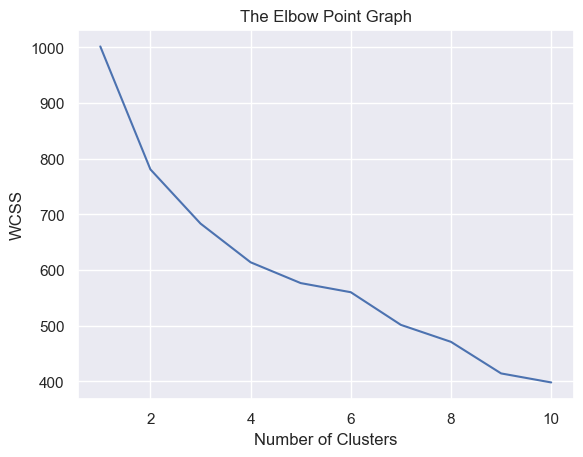

In [6]:
#plot an elbow graph
import seaborn as sns
import matplotlib.pyplot as plt


sns.set()
plt.plot(range(1,11), wcss)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [11]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=0)

# return a label for each data point based on their cluster
Y = kmeans.fit_predict(X)

print(Y)

[0 2 0 3 3 0 1 2 1 2 1 2 1 2 1 1 0 3 0 1 1 1 0 2 3 0 3 0 0 0 1 1 3 3 1 2 1
 1 1 1 2 3 0 1 0 1 0 3 3 0 3 3 1 2 2 0 2 1 3 3 2 0 2 2 2 0 3 3 2 2 3 1 1 2
 0 2 1 3 2 1 1 0 3 3 3 3 3 0 2 3 1 1 3 1 1 3 0 1 1 0 2 0 3 0 3 2 1 1 2 0 3
 2 3 3 2 3 0 1 2 1 3 1 1 2 2 1 0 1 3 0 1 1 2 1 3 3 1 0 0 1 1 1 0 3 3 0 1 3
 2 3 3 3 1 3 2 3 2 3 2 3 1 0 3 2 3 3 0 2 0 3 1 2 3 3 0 1 2 1 1 1 3 1 1 1 2
 1 0 3 0 2 1 0 1 0 2 1 2 2 1 2 0 1 3 1 2 0 0 0 3 0 3 2 1 2 3 3 1 3 1 2 0 2
 3 1 2 3 1 3 0 0 0 1 2 3 2 0 3 0 0 1 1 3 0 1 3 2 0 2 3 1 3 1 2 1 3 1 1 2 1
 2 1 0 3 1 2 2 2 1 1 3 1 1 3 2 0 1 1 1 1 1 0 1 3 2 2 1 1 3 0 1 3 2 1 2 2 2
 1 3 0 1 0 1 3 0 3 1 2 1 1 3 1 0 1 3 0 1 0 2 0 1 0 0 1 1 1 3 3 0 0 2 3 3 2
 1 1 3 2 0 1 3 3 3 3 1 0 1 1 1 1 0 1 0 1 2 1 2 0 0 1 0 0 1 1 1 0 0 0 1 3 0
 2 2 0 1 3 1 2 3 1 2 2 3 0 1 3 1 1 3 2 3 2 1 0 1 0 3 0 1 1 2 2 3 3 3 3 1 2
 3 1 1 1 1 0 3 3 1 0 1 1 0 1 1 3 2 1 2 1 3 1 0 3 1 1 1 1 3 3 2 1 3 0 2 2 3
 2 1 0 3 1 1 1 1 1 3 2 1 1 2 1 2 2 2 1 3 2 1 3 0 3 3 1 3 1 1 1 1 2 2 0 0 0
 3 2 1 3 0 0 2 2 0 1 2 0 

In [7]:
data["cluster"] = Y

for i in range(4):
  print(f"\n===== Cluster {i} =====")
  # unique -> NumPy array  like this ,array(['Data Scientist', 'AI Engineer'], dtype=object)
  print(data[data["cluster"] == i]["job_title"].unique())


'''
Step A: data["cluster"] == i when i = 0
[True, False, True, False, ...]
step B: data[data["cluster"] == i]

filtering with job belongs to which cluster


Example Cluster 0:

job_title	cluster
Data Scientist	0
AI Engineer	0

step C: ["job_title"]

final output:
"Data Scientist", "AI Engineer"]
'''

NameError: name 'Y' is not defined

**Working of this **

Original data:
Row 0 → cluster 0  
Row 1 → cluster 2  
Row 2 → cluster 0  

After filtering (i = 0):
Row 0  
Row 2

->Step 3: ["job_title"]

 Now you select only the job_title column

Data Scientist  
ML Engineer  
Data Analyst  

-> Step 4: .unique()

Removes duplicates

Example:

["Data Scientist", "Data Scientist", "ML Engineer"]

becomes:

["Data Scientist", "ML Engineer"]

In [23]:
# Making the predictive system
mlb = pickle.load(open("/content/mlb.pkl","rb"))
model = pickle.load(open("/content/job_model.pkl","rb"))

user_input = input("Enter skills (comma separated): ")

# ->  split() only changes structure once
# -> After that, you are NOT splitting again

user_skills = [i.strip().lower() for i in user_input.split(",")]

user_encoded = mlb.transform([user_skills])
# return a nested list
# print(user_encoded)

cluster_id = kmeans.predict(user_encoded)[0]
print("Cluster id- ", cluster_id)

job = model.predict(user_encoded)

print("Recommended job is: ",job[0])

print("Similar jobs Recommending the Cluster (KMeans): ")
similar_jobs = data[data["cluster"] == cluster_id]["job_title"].unique()
for i in similar_jobs:
  print(i)

Enter skills (comma separated): html,css,javascript
3
Recommended job is:  Software Developer
Similar jobs Recommending the Cluster (KMeans): 
Software Developer
